In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import os
import json

In [2]:
city = 'Mumbai'

df = pd.read_json(rf'../web scraping/{city}/car_dataset_{city.lower()}.json', lines=True)
df.head()

,url,car_name,Price,Registration Year,Insurance,Fuel Type,Seats,Kms Driven,RTO,Ownership,...,"<a href=""/car-faqs/mg-zs-ev/what-is-the-battery-capacity-of-mg-zs-ev-203.html"" class=""bluelink"" title=""Battery Capacity"">Battery Capacity</a>",Wireless Charging,Charger Type,Charging Time (15 A Plug Point),Charging Time (7.2 kW AC Fast Charger),Charging Time (50 kW DC Fast Charger),Petrol Mileage (ARAI),Approach Angle,Break-over Angle,Departure Angle
0,https://www.cardekho.com/used-car-details/used...,Honda Amaze,₹5.40 Lakh,2020,-,Petrol,5 Seats,"10,000 Kms",Mumbai,First Owner,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.cardekho.com/buy-used-car-details/...,Maruti Suzuki Vitara Brezza,₹6.49 Lakh,Dec 2020,Comprehensive,Petrol,5 Seats,"24,100 Kms",Mumbai,First Owner,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.cardekho.com/used-car-details/used...,Skoda Kushaq,₹9.45 Lakh,Nov 2021,-,Petrol,5 Seats,"37,212 Kms",Mumbai,First Owner,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,https://www.cardekho.com/used-car-details/used...,Volkswagen Ameo,₹3.55 Lakh,Nov 2016,Third Party,Petrol,5 Seats,"35,413 Kms",Mumbai,Second Owner,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,https://www.cardekho.com/used-car-details/used...,Maruti Suzuki Ciaz,₹6.60 Lakh,2019,-,Petrol,5 Seats,"40,000 Kms",Mumbai,First Owner,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
PROCESSED_FILES_LOG = 'processed_files.txt'

def get_processed_files():
    if os.path.exists(PROCESSED_FILES_LOG):
        with open(PROCESSED_FILES_LOG, 'r') as f:
            return f.read().splitlines()
    return []

def mark_file_as_processed(json_filename):
    processed = get_processed_files()
    if json_filename not in processed:
        with open(PROCESSED_FILES_LOG, 'a') as f:
            f.write(json_filename + '\n')

In [4]:
# ─────────────────────────────────────────
json_file = f'car_dataset_{city.lower()}.json'

if json_file in get_processed_files():
    print(f"⚠️ '{json_file}' already processed — skipping!")
    df = pd.read_csv('dataset.csv')  
    print(f"Loaded existing dataset with {len(df)} rows")
    
else:  
    req_col = []
    with open('features.txt', 'r') as f:
        features = f.read().split('\n')
    for i in features:
        if i in df.columns:
            req_col.append(i)
    # ✅ removed req_col.append('city')
    df = df[req_col]

    before = len(df)
    df = df.drop_duplicates()
    print(f"Duplicates removed from new data: {before - len(df)} rows")

    if os.path.exists('dataset.csv') and os.path.getsize('dataset.csv') > 0:
        existing_df = pd.read_csv('dataset.csv')
        combined_df = pd.concat([existing_df, df], ignore_index=True)

        before = len(combined_df)
        combined_df = combined_df.drop_duplicates()
        print(f"Duplicates removed from combined data: {before - len(combined_df)} rows")

        combined_df.to_csv('dataset.csv', index=False)
        print(f"Appended {len(df)} rows. Total rows: {len(combined_df)}")
    else:
        df.to_csv('dataset.csv', index=False)
        print(f"Created new dataset.csv with {len(df)} rows")

    mark_file_as_processed(json_file)
    print(f"✅ '{json_file}' marked as processed!")

⚠️ 'car_dataset_mumbai.json' already processed — skipping!
Loaded existing dataset with 1374 rows


In [5]:
df = pd.read_csv('dataset.csv')

In [6]:
df.columns

Index(['Engine', 'No. of Cylinders', 'Valves Per Cylinder',
       'Valve Configuration', 'Fuel Supply System', 'Fuel Type', 'Engine Type',
       'Emission Norm Compliance', 'Kerb Weight', 'Drive Type', 'Transmission',
       'Power'],
      dtype='object')

In [7]:
def handle_missing_values(df, col):
    missing_pct = df[col].isnull().mean() * 100
    print(f"{col}: {missing_pct:.2f}% missing", end=" → ")

    # Drop if more than 50% missing
    if missing_pct > 50:
        df.drop(columns=[col], inplace=True)
        print("❌ Dropped (>50% missing)")

    # Between 30% and 50% — drop rows
    elif missing_pct > 30:
        df.dropna(subset=[col], inplace=True)
        print("🗑️ Dropped rows (30-50% missing)")

    # Between 10% and 30% — fill with mean/mode + add indicator column
    elif missing_pct > 10:
        if df[col].dtype == 'object':
            fill_val = df[col].mode()[0]
            strategy = f"mode ({fill_val})"
        else:
            fill_val = df[col].mean()
            strategy = f"mean ({fill_val:.2f})"

        df[f'{col}_was_missing'] = df[col].isnull().astype(int)  # indicator column
        df[col].fillna(fill_val, inplace=True)
        print(f"⚠️ Filled with {strategy} + added indicator column (10-30% missing)")

    # Less than 10% — fill with median/mode
    elif missing_pct > 0:
        if df[col].dtype == 'object':
            fill_val = df[col].mode()[0]
            strategy = f"mode ({fill_val})"
        else:
            fill_val = df[col].median()
            strategy = f"median ({fill_val:.2f})"

        df[col].fillna(fill_val, inplace=True)
        print(f"✅ Filled with {strategy} (<10% missing)")

    else:
        print("✅ No missing values")

    return df


In [8]:
def one_hot_encode_with_info(df, column_name, prefix=None):
    
    if prefix is None:
        prefix = column_name

    # get categories
    categories = sorted(df[column_name].dropna().unique())

    print(f"\nFeature: {column_name}")
    print("All Categories:", categories)

    dropped_category = categories[0]
    print("Dropped Category:", dropped_category)

    # create dummies
    dummies = pd.get_dummies(
        df[column_name],
        prefix=prefix,
        drop_first=True
    )

    # add to dataframe
    df = pd.concat([df, dummies], axis=1)

    # drop original column
    df.drop(columns=[column_name], inplace=True)

    return df, dropped_category

In [9]:
# Fill the missing values

cols_with_missing = df.columns[df.isnull().any()].tolist()

for col in cols_with_missing:
    df = handle_missing_values(df, col)

Engine: 0.95% missing → ✅ Filled with mode (1197 cc) (<10% missing)
No. of Cylinders: 0.95% missing → ✅ Filled with median (4.00) (<10% missing)
Valves Per Cylinder: 0.95% missing → ✅ Filled with median (4.00) (<10% missing)
Valve Configuration: 40.03% missing → 🗑️ Dropped rows (30-50% missing)
Fuel Supply System: 7.16% missing → ✅ Filled with mode (MPFI) (<10% missing)
Fuel Type: 0.00% missing → ✅ No missing values
Engine Type: 0.61% missing → ✅ Filled with mode (Petrol Engine) (<10% missing)
Emission Norm Compliance: 10.80% missing → ⚠️ Filled with mode (BS IV) + added indicator column (10-30% missing)
Kerb Weight: 2.67% missing → ✅ Filled with mode (1100 kg) (<10% missing)
Drive Type: 7.16% missing → ✅ Filled with mode (FWD) (<10% missing)
Transmission: 0.00% missing → ✅ No missing values
Power: 2.67% missing → ✅ Filled with mode (67 bhp) (<10% missing)


1. Engine

In [10]:
df["Engine"] = (
    df["Engine"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)    
)

df["Engine"] = pd.to_numeric(df["Engine"], errors="coerce")


2. No. of Cylinders

In [11]:
# Nothing to do

3. Valves Per Cylinder

In [12]:
# Nothing to do

4. Fuel Supply System

In [13]:
def clean_fuel_supply(x):
    if pd.isna(x):
        return None

    x = str(x).strip().lower()

    if "mpfi" in x or "multi point" in x or "mpi" in x:
        return "MPFI"

    elif "crdi" in x or "common rail" in x or "tdci" in x or "ddis" in x or "cdi" in x:
        return "CRDI"

    elif "gdi" in x or "direct injection" in x:
        return "GDI"

    elif "efi" in x or "electronic fuel injection" in x or "electronic injection" in x:
        return "EFI"

    else:
        return "Other"


df["Fuel Supply System"] = df["Fuel Supply System"].apply(clean_fuel_supply)

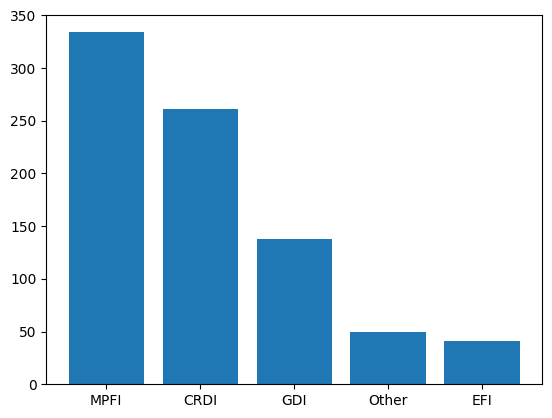

In [14]:
plt.bar(df['Fuel Supply System'].value_counts().index, df['Fuel Supply System'].value_counts().values)
plt.show()

In [15]:
df, dropped_fuel_sys = one_hot_encode_with_info(df, "Fuel Supply System", "FuelSys")


Feature: Fuel Supply System
All Categories: ['CRDI', 'EFI', 'GDI', 'MPFI', 'Other']
Dropped Category: CRDI


5. Fuel Type

In [16]:
# Drop all the row with 'Fuel Type' == 'Electric'
df = df[df['Fuel Type'] != 'Electric']

df, dropped_fuel_type = one_hot_encode_with_info(df, "Fuel Type", "Fuel")


Feature: Fuel Type
All Categories: ['CNG', 'Diesel', 'Petrol']
Dropped Category: CNG


6. 'Engine Type'

In [17]:
def clean_engine_type(value):
    if pd.isna(value):
        return 'Unknown'
    
    value = str(value).strip()
    
    # Kappa variants
    if 'Kappa' in value or 'kappa' in value:
        return 'Kappa'
    
    # K-Series variants
    if any(x in value for x in ['K10B', 'K10C', 'K12M', 'K12N', 'K14B', 'K15B', 'K15C', 'K Series', 'K series', 'k-series', 'Advanced K']):
        return 'K Series'
    
    # i-VTEC variants (Honda Petrol)
    if any(x in value for x in ['i-VTEC', 'i VTEC', 'iVTEC', '1.2L i-VTEC', '1.2 i-VTEC']):
        return 'i-VTEC'
    
    # i-DTEC variants (Honda Diesel)
    if any(x in value for x in ['i-DTEC', 'i DTEC']):
        return 'i-DTEC'
    
    # Revotron variants (Tata Petrol)
    if any(x in value for x in ['Revotron', 'REVOTRON']):
        return 'Revotron'
    
    # Revotorq variants (Tata Diesel)
    if any(x in value for x in ['Revotorq', 'REVOTORQ']):
        return 'Revotorq'
    
    # DDiS variants (Maruti Diesel)
    if any(x in value for x in ['DDiS', 'DDIS']):
        return 'DDiS'
    
    # IRDE2 variants (Bajaj)
    if 'IRDE2' in value:
        return 'IRDE2'
    
    # TSI variants (Volkswagen Petrol)
    if 'TSI' in value:
        return 'TSI'
    
    # TDI/TDCi/TDCI variants (Diesel)
    if any(x in value for x in ['TDI', 'TDCi', 'TDCI']):
        return 'TDI'
    
    # CRDi/CRDI variants (Hyundai/Kia Diesel)
    if any(x in value for x in ['CRDi', 'CRDI', 'CRDe']):
        return 'CRDi'
    
    # mHawk variants (Mahindra Diesel)
    if any(x in value for x in ['mHawk', 'mHAWk']):
        return 'mHawk'
    
    # mStallion variants (Mahindra Petrol)
    if 'mStallion' in value:
        return 'mStallion'
    
    # Kryotec variants (Tata)
    if any(x in value for x in ['Kryotec', 'KRYOJET']):
        return 'Kryotec'
    
    # SmartStream variants (Hyundai)
    if any(x in value for x in ['SmartStream', 'SMARTSTREAM', 'Smartstream']):
        return 'SmartStream'
    
    # F8D variants (Maruti)
    if 'F8D' in value:
        return 'F8D'
    
    # VVT variants
    if any(x in value for x in ['VVT', 'VTVT', 'VVTi', 'Ti-VCT']):
        return 'VVT'
    
    # TwinPower (BMW)
    if 'TwinPower' in value:
        return 'TwinPower'
    
    # D-4D variants (Toyota Diesel)
    if any(x in value for x in ['D-4D', '2KD-FTV', '2-GD FTV']):
        return 'Toyota Diesel'
    
    # Generic Petrol
    if 'Petrol' in value or 'petrol' in value:
        return 'Petrol'
    
    # Generic Diesel
    if 'Diesel' in value or 'diesel' in value:
        return 'Diesel'
    
    # In-Line
    if 'In-Line' in value or 'In Line' in value or 'Inline' in value:
        return 'In-Line'
    
    return 'Other'


# Apply
df['Engine Type'] = df['Engine Type'].apply(clean_engine_type)

In [18]:
df['Engine Type'].value_counts()

Engine Type
Petrol           158
Diesel           121
VVT               77
Other             70
i-VTEC            67
K Series          46
CRDi              41
DDiS              36
Kappa             34
In-Line           31
TDI               26
mHawk             22
Toyota Diesel     20
Revotron          18
i-DTEC            18
TSI               16
TwinPower          7
F8D                5
Revotorq           5
SmartStream        2
Kryotec            2
IRDE2              2
Name: count, dtype: int64

In [19]:
df, dropped_engine_type = one_hot_encode_with_info(
    df,
    "Engine Type",
    "EngineType"
)


Feature: Engine Type
All Categories: ['CRDi', 'DDiS', 'Diesel', 'F8D', 'IRDE2', 'In-Line', 'K Series', 'Kappa', 'Kryotec', 'Other', 'Petrol', 'Revotorq', 'Revotron', 'SmartStream', 'TDI', 'TSI', 'Toyota Diesel', 'TwinPower', 'VVT', 'i-DTEC', 'i-VTEC', 'mHawk']
Dropped Category: CRDi


7. 'Emission Norm Compliance'

In [20]:
def clean_emission_norm(x):

    if pd.isna(x):
        return None

    x = str(x).strip().lower()

    if "bs vi" in x or "bsvi" in x:
        return "BS6"

    elif "bs iv" in x or "bsiv" in x or "bharat stage iv" in x:
        return "BS4"

    elif "bs iii" in x or "bharat stage iii" in x:
        return "BS3"

    elif "euro" in x:
        return "EURO"

    else:
        return "Other"


df["Emission Norm Compliance"] = df["Emission Norm Compliance"].apply(clean_emission_norm)

In [21]:
df, dropped_emission_norm = one_hot_encode_with_info(df, "Emission Norm Compliance", "EmissionNorm")


Feature: Emission Norm Compliance
All Categories: ['BS3', 'BS4', 'BS6', 'EURO']
Dropped Category: BS3


8. 'Kerb Weight'

In [22]:
df['Kerb Weight'] = df['Kerb Weight'].str.extract(r'(\d+)').astype(float)

9. 'Drive Type'

In [23]:
def clean_drive_type(value):
    value = str(value).strip().upper().replace(' ', '')
    
    fwd_variants = ['FWD', '2WD', '4X2', 'FRONTWHEELDRIVE', 'TWOWHEELDRIVE', 'TWOWHHEELDRIVE', 'TWOWHHHEELDRIVE']
    rwd_variants = ['RWD', 'RWD(WITHMTT)']
    awd_variants = ['AWD', '4WD', '4X4']
    
    if value in fwd_variants:
        return 'FWD'
    elif value in rwd_variants:
        return 'RWD'
    elif value in awd_variants:
        return 'AWD'
    else:
        return 'FWD'

# Apply
df['Drive Type'] = df['Drive Type'].apply(clean_drive_type)

In [24]:
df, droped_drive_type = one_hot_encode_with_info(df, "Drive Type", "DriveType")


Feature: Drive Type
All Categories: ['AWD', 'FWD', 'RWD']
Dropped Category: AWD


10. 'Transmission'

In [25]:
transmission_map = {
    "Automatic": 1,
    "Manual": 0 
}

df['Transmission'] = df['Transmission'].map(transmission_map)

11. Power

In [26]:
df['Power'].head()

5      103.2 bhp
7         70 bhp
11      88.7 bhp
12    138.03 bhp
17    117.60 bhp
Name: Power, dtype: object

In [27]:
df['Power'] = df['Power'].str.replace(' bhp', '', regex=False).astype(float)


11. 'Valve Configuration'

In [28]:
def clean_valve_config(value):
    value = str(value).strip().upper()
    
    if 'DOHC' in value:
        return 'DOHC'
    elif 'SOHC' in value:
        return 'SOHC'
    else:
        return value

df['Valve Configuration'] = df['Valve Configuration'].apply(clean_valve_config)
print(df['Valve Configuration'].value_counts())

Valve Configuration
DOHC    694
SOHC    128
IDSI      2
Name: count, dtype: int64


In [29]:
df, dropped_valve_config = one_hot_encode_with_info(df, "Valve Configuration", "ValveConfig")


Feature: Valve Configuration
All Categories: ['DOHC', 'IDSI', 'SOHC']
Dropped Category: DOHC


'engine_density'

In [30]:
df['Engine Density'] = df['Engine'] / df['No. of Cylinders']

df['Engine Density'].head()

5     299.250000
7     497.666667
11    299.750000
12    739.000000
17    374.250000
Name: Engine Density, dtype: float64

In [31]:
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

In [32]:
df.columns

Index(['Engine', 'No. of Cylinders', 'Valves Per Cylinder', 'Kerb Weight',
       'Transmission', 'Power', 'Emission Norm Compliance_was_missing',
       'FuelSys_EFI', 'FuelSys_GDI', 'FuelSys_MPFI', 'FuelSys_Other',
       'Fuel_Diesel', 'Fuel_Petrol', 'EngineType_DDiS', 'EngineType_Diesel',
       'EngineType_F8D', 'EngineType_IRDE2', 'EngineType_In-Line',
       'EngineType_K Series', 'EngineType_Kappa', 'EngineType_Kryotec',
       'EngineType_Other', 'EngineType_Petrol', 'EngineType_Revotorq',
       'EngineType_Revotron', 'EngineType_SmartStream', 'EngineType_TDI',
       'EngineType_TSI', 'EngineType_Toyota Diesel', 'EngineType_TwinPower',
       'EngineType_VVT', 'EngineType_i-DTEC', 'EngineType_i-VTEC',
       'EngineType_mHawk', 'EmissionNorm_BS4', 'EmissionNorm_BS6',
       'EmissionNorm_EURO', 'DriveType_FWD', 'DriveType_RWD',
       'ValveConfig_IDSI', 'ValveConfig_SOHC', 'Engine Density'],
      dtype='object')

---

In [34]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, train_test_split 
from sklearn.metrics import r2_score, mean_absolute_error

In [35]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [36]:
X = df.drop(columns=['Power'], axis=1)
y = df['Power']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

In [38]:
 
best_model = grid_search.best_estimator_ 
y_pred = best_model.predict(X_test)

# 3. Quick evaluation
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):,.2f}")

R2 Score: 0.8513
Mean Absolute Error: 9.91


In [39]:
import os
import joblib
os.makedirs("model", exist_ok=True)
joblib.dump(best_model, "model/power_model.pkl")
print("Model saved!")

Model saved!


> In the next step we will be testing the model performance with different size of data